In [91]:
import numpy as np
from os import listdir, makedirs
import matplotlib.pyplot as plt
from datetime import datetime
from  random import choices, choice

import torch
import torch.onnx
from torch import nn
import torch.optim as optim
from torch.utils.data import Dataset, SubsetRandomSampler, DataLoader, random_split

from sklearn.model_selection import KFold, train_test_split

from tqdm.notebook import tqdm
import pickle
import warnings

warnings.filterwarnings( "ignore", module = "matplotlib" )

plt.style.use("seaborn-pastel")
torch.use_deterministic_algorithms(True)
torch.manual_seed(42)

## Setup

In [92]:
class build_autoencoder(nn.Module):
    def __init__(self, config):
        """
        # build_network

        __init__(layer_number = "3", layer_conv = None, layer_type = "Linear", activation_type = "ReLU", half=False)

        Build neural network with desired caracteristics. 

        - activation_list (list) : List of the activation function used in the network.
                                    - Available choices : "ReLU", "Sigmoid", "CELU", "Softmax", "Softmin", "Hardshrink", 
                                                          "LeakyReLU", "ELU", "LogSigmoid", "PReLU", "GELU", "SiLU", 
                                                          "Mish", "Softplus", "Softsign", "Tanh", "GLU", "Threshold"
        - input_dimension (int) : Number of input in the encoder.
        - output_dimension (int) : Number of output in the encoder.
        - layer_number (int) : Number of hidden layer in the autoencoder network (needs to be an even number).
        - layer_type (str) : Type of layer used.
                                - Available choices : "Linear"
        """
        super(build_autoencoder, self).__init__()
        
        if config['run']['layer_number'] % 2 != 0:
            print("Invalid number of layer (needs to be even number)")

        # Layer type
        layer_type_dict = {
            "Linear" : nn.Linear
        }
        layer = layer_type_dict[config['network']['layer_type']]

        # Activation function
        activation_dict = {
            "ReLU"       : nn.ReLU,
            "Sigmoid"    : nn.Sigmoid,
            "CELU"       : nn.CELU, 
            "Softmax"    : nn.Softmax,
            "Softmin"    : nn.Softmin,
            "Hardshrink" : nn.Hardshrink,
            "LeakyReLU"  : nn.LeakyReLU,
            "ELU"        : nn.ELU,
            "LogSigmoid" : nn.LogSigmoid,
            "PReLU"      : nn.PReLU,
            "GELU"       : nn.GELU,
            "SiLU"       : nn.SiLU,
            "Mish"       : nn.Mish,
            "Softplus"   : nn.Softplus,
            "Softsign"   : nn.Softsign,
            "Tanh"       : nn.Tanh,
            "GLU"        : nn.GLU,
            "Threshold"  : nn.Threshold,
        }

        # Number of layer
        #encoder_layers = np.linspace(config["input_dimension"], config["output_dimension"], int(config['layer_number'] / 2 + 1), dtype=int)
        #layer_list = np.concatenate((encoder_layers, np.flip(encoder_layers)[1:]))
        layer_list = config['run']['layer_list']
        layer_list[0] = layer_list[-1] = config['internal']['input_dimension']
        activation_list = config['run']['activation_list']
        
        # Build network
        self.encoder = nn.Sequential()
        self.decoder = nn.Sequential()

        self.encoder.append(nn.Conv1d(1, 1, kernel_size=21, stride=1, padding='same'))
        self.encoder.append(nn.Conv1d(1, 1, kernel_size=21, stride=1, padding='same'))
        
        for index, activation_type in enumerate(activation_list):
            if index < len(activation_list) // 2 + 1:
                self.encoder.append(layer(layer_list[index], layer_list[index+1]))
                self.encoder.append(activation_dict[activation_type]())
            else:
                self.decoder.append(layer(layer_list[index], layer_list[index+1]))
                self.decoder.append(activation_dict[activation_type]())
            
        self.decoder.append(layer(layer_list[-2], layer_list[-1]))

        self.decoder.append(nn.Conv1d(1, 1, kernel_size=21, stride=1, padding='same'))
        self.decoder.append(nn.Conv1d(1, 1, kernel_size=21, stride=1, padding='same'))

    def forward(self, x, encoding=False, decoding=False):
        
        if encoding:
            return self.encoder(x)
        elif decoding:
            return self.decoder(x)
        else:
            encode = self.encoder(x)
            decode = self.decoder(encode)
        return decode
        

In [93]:
class TESdataset(Dataset):
    def __init__(self, config):
        self.skip = config['network']["skip_elements"]
        self.folder = f"Datasets/{config['files']['dataset']}"
        self.files = listdir(self.folder)

        temp_file = np.load(f"{self.folder}/{self.files[0]}", allow_pickle=True)
        self.size = int(np.shape(temp_file)[1])
        del temp_file

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):

        try:
            TES = np.load(f"{self.folder}/{self.files[index]}", allow_pickle=True)
            
            if self.skip > 1: TES = [i[1::self.skip] for i in TES]
        except Exception as ex:
            print("Error during loading process : ", ex)
        return torch.stack(np.array(TES, dtype="float32"))
    
    def input_size(self):
        return self.size
    

In [94]:
def custom_dataloader(config, files):
    skip = config['network']["skip_elements"]
    folder = f"Datasets/{config['files']['dataset']}"
    size = config['internal']['input_dimension']

    TES = np.concatenate([np.load(f"{folder}/{file_name}", allow_pickle=True) for file_name in files])
    
    if skip > 1: TES = [i[1::skip] for i in TES]

    return torch.tensor(np.array(TES, dtype="float32")).view(-1,1,size)

In [95]:
def custom_kfold(config):
    """
    # custom_kfold


    """
    folder = f"Datasets/{config['files']['dataset']}"
    skip = config['network']["skip_elements"]
    files = listdir(folder)
    input_dimension = np.shape(np.load(f"{folder}/{files[0]}", allow_pickle=True))[1]
    config['internal']['input_dimension'] = int(input_dimension / skip)


    # 
    fold = KFold(n_splits=config['train']['k-fold'],shuffle=True,random_state=42)
    train_validation_files, test_files = train_test_split(files,train_size=config['train']['train_size'],shuffle=True)
    splits = fold.split(train_validation_files)

    train_files = []
    validation_files = []

    for train_index, validation_index in splits:
        train_files.append(np.take(train_validation_files, train_index))
        validation_files.append(np.take(train_validation_files, validation_index))

    train_batch_number = validation_batch_number = config['train']['batch_number']
    
    batch_max = len(train_files[0])
    if train_batch_number >= batch_max:
        warnings.warn(f"Batch number too high, was set to {batch_max} (maximum)")
        train_batch_number = batch_max
    
    batch_max = len(validation_files[0])
    if validation_batch_number >= batch_max:
        validation_batch_number = batch_max
    
    train_files = [np.array_split(train_fold, train_batch_number) for train_fold in train_files]
    validation_files = [np.array_split(validation_fold, validation_batch_number) for validation_fold in validation_files]

    return train_files, validation_files, test_files, config

In [96]:
def build_optimizer(network, config):
    """
    # build_optimizer

    build_optimizer(network, learning_rate, optimizer_name="adam")

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - learning_rate (float) : Learning rate used in the optimizer.
    - optimizer_type ("sgd", "adam") : Type of optimizer used in the training process.
    """

    optimizer_dict = {
        "SGD"  : optim.SGD,
        "adam" : optim.Adam
    }

    return optimizer_dict[config['train']['optimizer']](network.parameters(), lr=config['train']['learning_rate'])
    

In [97]:
def build_criterion(config):
    """
    # build_criterion

    build_criterion(criterion_name="CrossEntropy")

    - criterion_type ("CrossEntropy", "L1Loss") : Type ocriterion used in the training process.
    """
    criterion_dict = {
        "CrossEntropy"       : nn.CrossEntropyLoss(),
        "L1Loss"             : nn.L1Loss(),
        "MSELoss"            : nn.MSELoss(),
        "NLLLoss"            : nn.NLLLoss(),
        "HingeEmbeddingLoss" : nn.HingeEmbeddingLoss(),
        "MarginRankingLoss"  : nn.MarginRankingLoss(),
        "TripletMarginLoss"  : nn.TripletMarginLoss(),
        "KLDivLoss"          : nn.KLDivLoss()
    }
    
    return criterion_dict[config['train']['criterion']]

In [98]:
def train_epoch(config, network, X_train, optimizer, criterion):
    """
    # train_epoch

    train_epoch(network, loader, optimizer, criterion, batch_size)

    Training process executed for every epoch. The actions consists of setting the gradients to zero, 
    making predictions for the batch, computing the loss and its gradientand updating the weights and biases.

    - network (Pytorch Sequential) : Bowtie neural network that is trained to reproduce its input signal.
    - loader (Pytorch tensor) :  Dataset
    - optimizer (Pytorch optimizer) : Optimizer used for training.
    - criterion(Pytorch optimizer) : Criterion used for training.
    - batch_size (int) : Size of the dataset.
    """
    cumu_loss = 0
    network.train()
    for data in X_train:
        # Use cuda if available
        data = data.to(config['internal']['device'])
        # Zero gradient
        optimizer.zero_grad()
        # Forward
        loss = criterion(network(data), data)
        # Backward
        loss.backward()
        optimizer.step()
        # Loss
        cumu_loss += loss.item()

    return cumu_loss, len(X_train)

In [99]:
def save_object(save_object, file_name):
    """
    # save_object

    save_object(save_object, file_name)

    
    """
    try:
        with open(f"{file_name}.bin", 'wb') as f:
            pickle.dump(save_object, f)
        #np.save(f'{file_name}', arr=save_object, allow_pickle=True)
    except Exception as ex:
        print("Error during saving process : ", ex)

In [100]:
def open_object(file_name):

    try:
        with open(file_name, 'rb') as f:
            dictionary = pickle.load(f)
    except Exception as ex:
        print("Error when loading file : ", ex)

    return dictionary

In [101]:
def validation_test(config, network, X, criterion, store=False):
    """
    """
    lenght = len(X)
    results = {'encode1'     : [],
               'encode2'     : [],
               'decode'      : [],
               'input'       : []
               }

    cumu_loss = 0
    network.eval()
    with torch.no_grad():
        for index, data in enumerate(X):
            # Use cuda if available
            data = data.to(config['internal']['device'])

            if store:
                
                encode = network(data, encoding=True)
                decode = network(encode, decoding =True)

                save_encode = torch.clone(encode).numpy()
                results["encode1"].append(save_encode[0,0])
                results["encode2"].append(save_encode[0,1])

                if index > 3:
                    save_input = torch.clone(data).numpy()
                    results["input"].append(save_input[0])

                    save_encode = torch.clone(decode).numpy()
                    results["decode"].append(save_encode[0])
            else:
                decode = network(data)
                
            loss = criterion(decode, data)
            cumu_loss += loss.item()

    if store:
        return cumu_loss / lenght, results
    
    return cumu_loss, lenght

In [102]:
def save_all(log_path, network, results, loss, config):
        torch.save(network.state_dict() , f"{log_path}/model.pt")

        save_object(results , f"{log_path}/results")
        save_object(loss , f"{log_path}/loss")
        save_object(config, f"{log_path}/log")

In [103]:
def train(config):
    """
    # train

    train(config)

    Execute a neural network experiment by creating an autoencoder neural network and training it to reproduce the it's input signal.
    Once it is trained, the encoder portion is used to associate each signal to a singular value. 
    This way, the network acts as a dimensionality reduction technique.

    - config (dict) : Dictionary with the configuration parameters
        - example : config = {
            'files' : {
                    'dataset'              : 'Thomas Gerrits',
                    'path_save'            : 'Autoencoder Log/',
                    },
            'sweep' : {
                    'sweep_index'          : None,
                    'sweep_name'           : None,
                    'activation_possibilty': ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
                    'search_type'          : 'random_search',
                    'search_param'        : ['activation_possibilty']
                    },
            'run' : {
                    'activation_list'      : ['ReLU', 'Sigmoid', 'ReLU'],
                    },
            'network' : {
                    'layer_number'         : 4,
                    'input_dimension'      : 496,
                    'output_dimension'     : 2,
                    'layer_type'           : 'Linear',
                    'layer_conv'           : True
                    },
            'train' : {
                    'k-fold'               : 3, 
                    'optimizer'            : 'adam',
                    'criterion'            : 'MSELoss',
                    'epochs'               : 1,
                    'learning_rate'        : 1e-4,
                    }
            }
    """
    config['internal'] = {}
    config['internal']['device'] = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # log path and folder creation to store results
    if config['sweep']['sweep_name'] is not None:
        log_path = f"{config['files']['path_save']}/{config['sweep']['sweep_name']}/sweep {config['internal']['sweep_index']}"
    else:
        folder_name = datetime.now().strftime(r"%Y-%m-%d-%H-%M")
        log_path = f"{config['files']['path_save']}/run-{folder_name}"

    train_files, validation_files, test_files, config = custom_kfold(config)

    for fold_index in tqdm(range(config['train']['k-fold']), desc="Fold", total=config['train']['k-fold']):

        # Initialization of loss and result arrays
        loss = {'train_loss'        : [], 
                'validation_loss'   : [],
                'test_loss'         : [],
                'average_test_loss' : []
                }
    
        network = build_autoencoder(config).float().to(config['internal']['device'])
        optimizer = build_optimizer(network, config)
        criterion = build_criterion(config)

        for epoch in tqdm(range(config['train']['epochs']), desc="Epoch"):
            
            train_loss = validation_loss = train_number = validation_number = 0

            for batch_files in train_files[fold_index]:   
            
                X_train = custom_dataloader(config, batch_files)
                
                train_loss_, train_number_ = train_epoch(config, network, X_train, optimizer, criterion)
                train_loss += train_loss_
                train_number += train_number_

            for batch_files in validation_files[fold_index]:

                X_validation = custom_dataloader(config, batch_files)

                validation_loss_, validation_number_ = validation_test(config, network, X_validation, criterion)
                validation_loss += validation_loss_
                validation_number += validation_number_

            loss['train_loss'].append(train_loss/train_number)
            loss['validation_loss'].append(validation_loss/validation_number)
        
        X_test = custom_dataloader(config, test_files)
        test_loss , results = validation_test(config, network, X_test, criterion, store=True)
        loss['test_loss'].append(test_loss)
 
        fold_path = f"{log_path}/fold {fold_index}"
        makedirs(fold_path)
        save_all(fold_path, network, results, loss, config)

In [104]:
def sweep(name, test_number, config):
    """
    # Sweep 

    sweep(name, test_number, config)

    Train randomly created neural networks (change the activation functions). 
    The activation function are defined to keep the autoencoder structure.

    name (str) : Name of the folder created to store the runs.
    test_number (int) : Number of model to create and train.
    config (dict) : Configuration parameters to create the autoencoders.

    TODO
    - Find criteria for dimensionality reduction and add it to the sweep
    """
    #config['internal'] = {}
    config['sweep']['sweep_name'] = name
    config_run = config.copy()
    config_run['internal']['sweep_index'] = 0
    layer_number = config_run['run']['layer_number']

    
    # Creat random test
    if config['sweep']['search_type'] == 'random_search':
        pbar = tqdm(total=test_number)
        while config_run['internal']["sweep_index"] <= test_number:

            if 'layer_possibility' in config['sweep']['search_param']:
                    layer_number = choice(config['sweep']['layer_possibility']['number'])
                    layer_list = choices(config['sweep']['layer_possibility']['size'], k = int(layer_number / 2))
                    layer_list.append(config['network']['output_dimension'])
                    
                    config_run['run']['layer_list'] = layer_list + list(reversed(layer_list))[1:]
                    config_run['run']['layer_number'] = layer_number

            for parameter in config['sweep']['search_param']:

                if parameter == 'activation_possibilty':
                    activation_list = choices(config['sweep'][parameter], k = int(layer_number / 2))
                    config_run['run']['activation_list'] = activation_list + list(reversed(activation_list))[1:]
                elif parameter == 'layer_possibility':
                    pass
                else:
                    config_run['sweep'][parameter] = choice(config[parameter])
                
            # Train the newly created config
            train(config_run)
            # Only save the results if the results meet threshold criteria
            config_run['internal']['sweep_index'] += 1
            pbar.update(1)
        pbar.close()
    """
    elif config['sweep']['search_type'] == 'grid_search':
        for parameter in tqdm(config['sweep']['search_param']):
            for value in config[parameter]:
                config_run[parameter] = value
                # Train the newly created config
                threshold = train(config_run)
                config_run['sweep_index'] +=1
    """

## Configuration 

In [105]:
config = {
'files' : {
        'dataset'                : 'Guillaume Thekkadath',
        'path_save'              : 'Autoencoder Log/',
        },
'sweep' : {
        'sweep_name'             : None,
        'activation_possibilty'  : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                        'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                        'Mish', 'Softplus', 'Softsign', 'Tanh'],
        'layer_possibility'      : {'number' : [4],
                                    'size'   : [5,50,100,200],
                                   },
        'search_type'            : 'random_search',
        'search_param'           : ['activation_possibilty','layer_possibility']
        },
'run' : {
        'activation_list'        : ['ReLU', 'Sigmoid', 'ReLU'],
        'layer_list'             : [400, 10, 2, 10, 400],
        'layer_number'           : 4
        },
'network' : {
        'output_dimension'       : 2,
        'skip_elements'          : 1,
        'layer_type'             : 'Linear',
        'layer_conv'             : True
        },
'train' : {
        'train_size'             : 0.8,
        'batch_number'           : 1,
        'k-fold'                 : 2, 
        'optimizer'              : 'adam',
        'criterion'              : 'MSELoss',
        'epochs'                 : 20,
        'learning_rate'          : 5e-7,
        }
}

#sweep("sweep-conv-1", 10, config)
threshold = train(config)

Fold:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch:   0%|          | 0/20 [00:00<?, ?it/s]

## Load 

In [106]:
def load_results(file_name):
    warnings.filterwarnings("ignore")
    path = f"Autoencoder Log/{file_name}"
    

    for index, fold in enumerate(listdir(path)):

        fig, axs = plt.subplots(2,2,figsize=(15,8))

        results = open_object(f"{path}/{fold}/results.bin")
        
        axs[0,0].scatter(results['encode1'], results['encode2'],label=f"fold {index}",s=5,alpha=0.01)
        axs[0,0].set_xlabel("feature 1")
        axs[0,0].set_ylabel("feature 2")
        leg = axs[0,0].legend()
        for lh in leg.legendHandles: 
            lh.set_alpha(1)

        axs[1,0].plot(results['decode'][0],label=f"Autoencoder output {index}")
        axs[1,0].plot(results['input'][0],label=f"Autoencoder input {index}")
        axs[1,0].set_ylabel("Normalized voltage")
        axs[1,0].set_xlabel("element")
        axs[1,0].legend()

        axs[1,1].plot(results['decode'][1],label=f"Autoencoder output {index}")
        axs[1,1].plot(results['input'][1],label=f"Autoencoder input {index}")
        axs[1,1].set_ylabel("Normalized voltage")
        axs[1,1].set_xlabel("element")
        axs[1,1].legend()

        loss = open_object(f"{path}/{fold}/loss.bin")

        axs[0,1].plot(loss['train_loss'],label=f"Train {index}")
        axs[0,1].plot(loss['validation_loss'],label=f"Validation {index}")
        axs[0,1].hlines(loss['test_loss'], 0, len(loss['validation_loss'])-1, linestyles='dashed',label = f"Test {index}")
        axs[0,1].legend()
        axs[0,1].set_ylabel("loss")
        axs[0,1].set_xlabel("epoch")

    config_file = open_object(f"{path}/{fold}/log.bin")
    print("Activation list : ", config_file['run']['activation_list'])
    print("Layer list : ", config_file['run']['layer_list'])

Activation list :  ['ReLU', 'Sigmoid', 'ReLU']
Layer list :  [496, 10, 2, 10, 496]


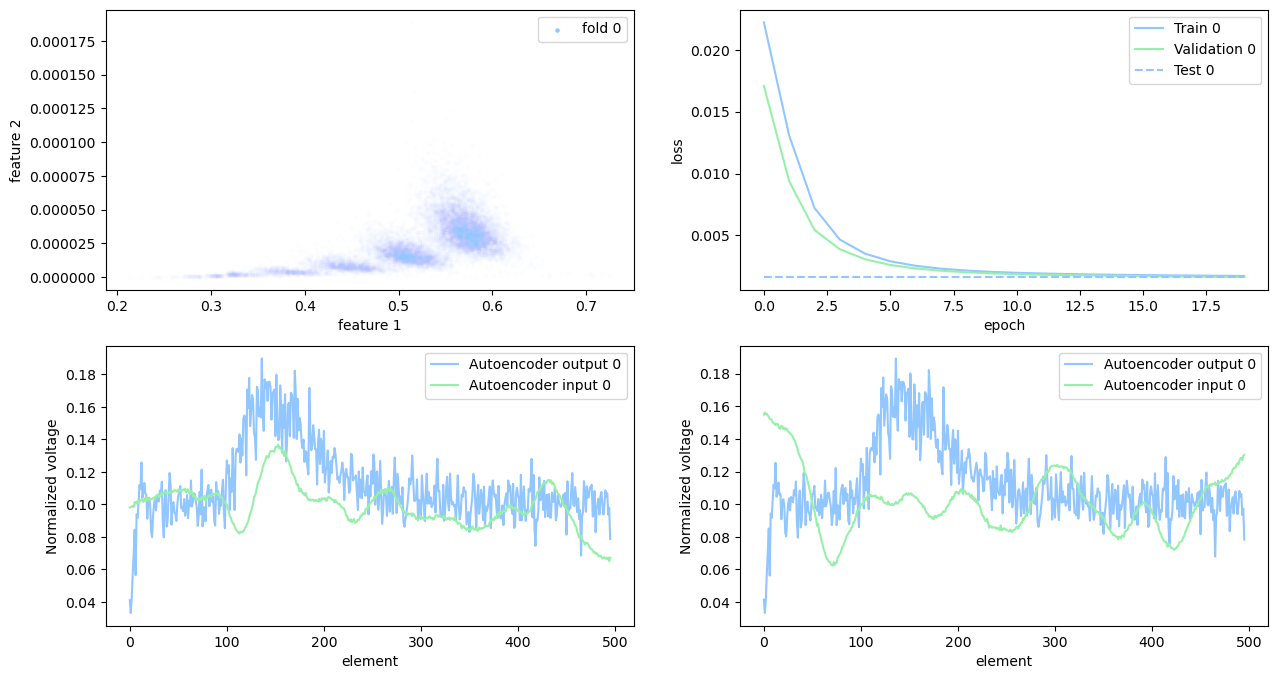

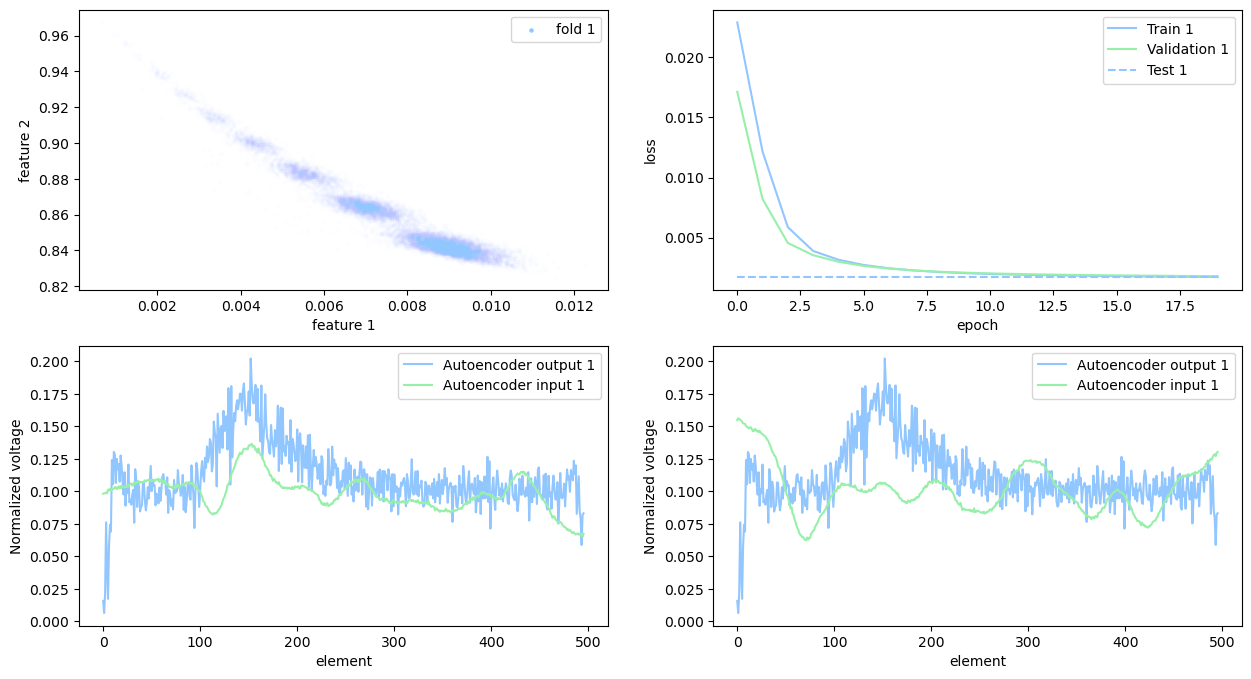

In [108]:
load_results("run-2023-06-26-12-51")